# AssureX Claim Engine — Final Model Evaluation & Export

Based on the validation comparison, XGBoost is refit on training + validation data and evaluated once on the untouched test split. The notebook produces the required accuracy, precision, recall, F1-score, class-wise results, confusion matrix, confidence probabilities, and an exportable model artifact.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, log_loss, ConfusionMatrixDisplay
from xgboost import XGBClassifier

from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
DATA_NAME = "assurex_nigeria_warranty_claims_v2.csv"
CANDIDATES = [
    Path('/mnt/data') / DATA_NAME,
    Path(DATA_NAME),
    Path('../data') / DATA_NAME,
]
DATA_PATH = next((p for p in CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Place {DATA_NAME} beside the notebook or in ../data/")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")

def engineer_features(frame):
    frame = frame.copy()
    for col in ['manufacture_date', 'purchase_date', 'fault_date', 'claim_date']:
        frame[col] = pd.to_datetime(frame[col], errors='coerce')
    frame['manufacture_to_purchase_days'] = (frame['purchase_date'] - frame['manufacture_date']).dt.days
    frame['purchase_to_fault_days'] = (frame['fault_date'] - frame['purchase_date']).dt.days
    frame['fault_to_claim_days'] = (frame['claim_date'] - frame['fault_date']).dt.days
    frame['claim_month'] = frame['claim_date'].dt.month
    return frame

# Keep business-rule outputs independent of the ML classifier.
# This avoids letting the Python model merely learn the final rule-engine result.
EXCLUDED_COLUMNS = {
    'claim_id', 'provenance_ref', 'split', 'claim_class',
    'manufacture_date', 'purchase_date', 'fault_date', 'claim_date', 'warranty_expiry_date',
    'fault_description', 'claim_narrative',
    'warranty_status', 'official_channel_status', 'fault_coverage_status',
    'serial_match_status', 'proof_of_purchase_status', 'duplicate_claim_indicator',
    'contradiction_flag', 'unauthorized_repair_flag', 'tamper_flag',
    'reported_within_return_window', 'statutory_3_month_window'
}

df_model = engineer_features(df)
FEATURE_COLUMNS = [c for c in df_model.columns if c not in EXCLUDED_COLUMNS]
X = df_model[FEATURE_COLUMNS]
y = df_model['claim_class']


Loaded: assurex_nigeria_warranty_claims_v2.csv
Shape: (2400, 57)


In [5]:
trainval_mask = df_model['split'].isin(['train','validation'])
test_mask = df_model['split'].eq('test')
X_trainval, y_trainval = X[trainval_mask], y[trainval_mask]
X_test, y_test = X[test_mask], y[test_mask]

num_cols = X_trainval.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in X_trainval.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

label_encoder = LabelEncoder().fit(y_trainval)

In [6]:
model = XGBClassifier(
    n_estimators=350, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    objective='multi:softprob', eval_metric='mlogloss',
    random_state=42, n_jobs=-1
)
final_pipeline = Pipeline([('preprocess', preprocessor), ('model', model)])
final_pipeline.fit(X_trainval, label_encoder.transform(y_trainval))
print('Final model trained on:', len(X_trainval), 'claims')
print('Untouched test claims:', len(X_test))

Final model trained on: 2040 claims
Untouched test claims: 360


In [7]:
test_pred_encoded = final_pipeline.predict(X_test).astype(int)
test_pred = label_encoder.inverse_transform(test_pred_encoded)
test_proba = final_pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, test_pred)
macro_f1 = f1_score(y_test, test_pred, average='macro')
print(f'Test accuracy: {acc:.4f}')
print(f'Test macro F1: {macro_f1:.4f}')
print(f'Log loss: {log_loss(y_test, test_proba, labels=list(label_encoder.classes_)):.4f}')

Test accuracy: 0.9278
Test macro F1: 0.9275
Log loss: 0.3138


In [8]:
report_df = pd.DataFrame(classification_report(y_test, test_pred, output_dict=True)).T
display(report_df.round(4))

,precision,recall,f1-score,support
Likely Invalid,0.9727,0.8917,0.9304,120.0000
Likely Valid,0.8824,1.0000,0.9375,120.0000
Manual Review Required,0.9386,0.8917,0.9145,120.0000
accuracy,0.9278,0.9278,0.9278,0.9278
macro avg,0.9312,0.9278,0.9275,360.0000
weighted avg,0.9312,0.9278,0.9275,360.0000


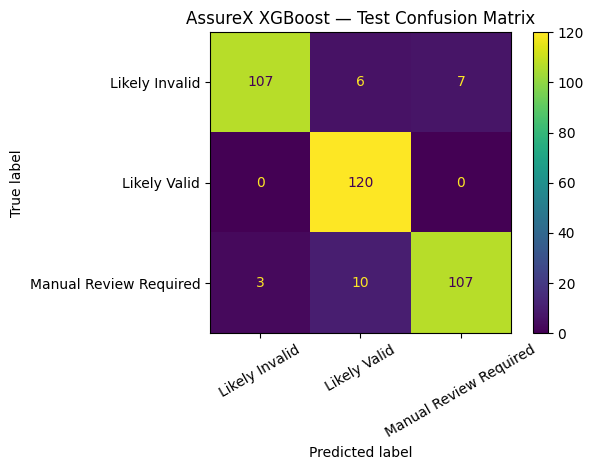

,Likely Invalid,Likely Valid,Manual Review Required
Likely Invalid,107,6,7
Likely Valid,0,120,0
Manual Review Required,3,10,107


In [9]:
cm = confusion_matrix(y_test, test_pred, labels=label_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(values_format='d', xticks_rotation=30)
plt.title('AssureX XGBoost — Test Confusion Matrix')
plt.tight_layout()
plt.show()
pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

## Confidence-score examples

The SRS requires confidence values for all three claim classes. XGBoost's `predict_proba()` supplies those class probabilities.

In [10]:
confidence_df = pd.DataFrame(test_proba, columns=[f'confidence_{c}' for c in label_encoder.classes_], index=X_test.index)
examples = df_model.loc[X_test.index, ['claim_id','claim_class']].copy()
examples['predicted_class'] = test_pred
examples = pd.concat([examples.reset_index(drop=True), confidence_df.reset_index(drop=True)], axis=1)
display(examples.head(10).round(4))

,claim_id,claim_class,predicted_class,confidence_Likely Invalid,confidence_Likely Valid,confidence_Manual Review Required
0,NG-WC-01945,Likely Valid,Likely Valid,0.0020,0.9913,0.0067
1,NG-WC-00780,Likely Invalid,Likely Invalid,0.9610,0.0048,0.0342
2,NG-WC-01268,Manual Review Required,Manual Review Required,0.0019,0.0001,0.9980
3,NG-WC-02325,Likely Valid,Likely Valid,0.0078,0.9632,0.0290
4,NG-WC-00582,Likely Invalid,Likely Invalid,0.9985,0.0003,0.0012
5,NG-WC-01363,Likely Valid,Likely Valid,0.0030,0.9785,0.0185
6,NG-WC-01869,Likely Valid,Likely Valid,0.0185,0.9520,0.0295
7,NG-WC-01379,Likely Valid,Likely Valid,0.0248,0.9441,0.0311
8,NG-WC-00846,Manual Review Required,Manual Review Required,0.0525,0.1191,0.8284
9,NG-WC-00394,Likely Valid,Likely Valid,0.0048,0.9715,0.0237


## Feature importance

These importances are useful evidence for the project report. They describe which encoded inputs the final XGBoost model relied on most strongly; they do not replace the warranty-rule explanation layer.

,feature,importance
225,cat__damage_cause_manufacturing_defect,0.055807
223,cat__damage_cause_liquid_damage,0.034630
88,cat__product_category_Air Conditioner,0.033530
230,cat__damage_cause_unauthorized_repair,0.033327
11,num__fault_to_claim_days,0.032678
209,cat__fault_category_software_issue,0.027078
262,cat__prior_repair_authorized_False,0.026161
231,cat__damage_cause_uncertain,0.025630
5,num__reporting_delay_days,0.023020
228,cat__damage_cause_power_surge,0.022465


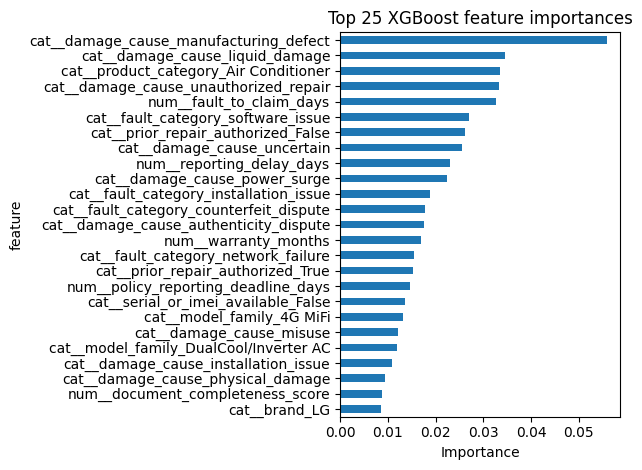

In [11]:
feature_names = final_pipeline.named_steps['preprocess'].get_feature_names_out()
importances = final_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(25)
display(importance_df)
ax = importance_df.sort_values('importance').plot(kind='barh', x='feature', y='importance', legend=False, title='Top 25 XGBoost feature importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Export model and evaluation artifacts

In [8]:
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump({
    'pipeline': final_pipeline,
    'label_encoder': label_encoder,
    'feature_columns': FEATURE_COLUMNS,
    'excluded_columns': sorted(EXCLUDED_COLUMNS)
}, ARTIFACT_DIR / 'assurex_xgboost_final.joblib')

report_df.to_csv(ARTIFACT_DIR / 'classification_report.csv')
pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_).to_csv(ARTIFACT_DIR / 'confusion_matrix.csv')
examples.to_csv(ARTIFACT_DIR / 'sample_test_predictions_with_confidence.csv', index=False)
importance_df.to_csv(ARTIFACT_DIR / 'feature_importance_top25.csv', index=False)

print('Saved artifacts to:', ARTIFACT_DIR.resolve())

Saved artifacts to: /mnt/data/artifacts


## Final result

On this dataset, the selected XGBoost model exceeds the SRS minimum target of 85% unseen-test accuracy.